In [1]:
import pandas as pd

df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

In [3]:
import pandas as pd

# 1. 데이터 로드 (세 번째 시트인 Data_invivo를 로드)
df = pd.read_excel('skin_irritation.xlsx', sheet_name=2)

# 2. 필터링 및 타겟 설정
# Mixture: Chemical, Species: Human, Endpoint: Positive reaction 데이터만 추출
df_filtered = df[
    (df['Mixture'] == 'Chemical') & 
    (df['Species'] == 'Human') & 
    (df['Endpoint'] == 'Positive reaction')
].copy()

# 3. Response 컬럼을 수치 데이터(Y)로 변환
# 선형 회귀를 위해 숫자로 변환하며, 변환 불가능한 값(문자열 등)은 NaN으로 처리
df_filtered['y_value'] = pd.to_numeric(df_filtered['Response'], errors='coerce')

# 4. 결측치 제거
# SMILES가 없거나, 수치 변환이 실패한(NaN) 데이터는 제거
df_task1 = df_filtered.dropna(subset=['SMILES', 'y_value']).reset_index(drop=True)

# 필요한 컬럼만 선택 (SMILES와 수치 타겟 y_value)
df_task1 = df_task1[['SMILES', 'y_value']]

print(f"회귀 모델용 데이터 개수: {len(df_task1)}")
print(df_task1.head())

회귀 모델용 데이터 개수: 70
                                          SMILES  y_value
0                                        CC(O)CO     6.25
1                                      CCCCCCC=O    58.60
2                       CCCCCCCCCCCCCC(=O)OC(C)C     3.30
3  C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|     0.00
4                                    [OH-].[Na+]    60.60


In [16]:
from rdkit import Chem
from rdkit.Chem import SaltRemover

# RDKit의 염 제거기 설정
remover = SaltRemover.SaltRemover()

def standardize_smiles(smi):
    try:
        # SMILES 문자열을 Mol 객체로 변환
        mol = Chem.MolFromSmiles(smi)
        if mol:
            # (ㄱ) 염 제거 (Strip salts like Cl-, Na+, etc.)
            mol = remover.StripMol(mol)
            
            # (ㄴ) SMILES 표준화 (Canonical & Isomeric SMILES)
            # 동일한 구조는 항상 하나의 고유한 문자열로 변환됩니다.
            return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
        return None
    except:
        return None

print("--- [Step ㄱ, ㄴ] 염 제거 및 표준화 시작 ---")

# (ㄱ, ㄴ) 로직 적용하여 새로운 컬럼 생성
df_task1['smiles_std'] = df_task1['SMILES'].apply(standardize_smiles)

# 표준화 실패(None)한 데이터 제거 및 정리
df_step12 = df_task1.dropna(subset=['smiles_std']).copy()
df_step12 = df_step12.reset_index(drop=True)

print(f"원래 데이터 개수: {len(df_task1)}")
print(f"표준화 후 데이터 개수: {len(df_step12)}")
print(f"삭제된 무효 SMILES 수: {len(df_task1) - len(df_step12)}")

# 결과 상위 5개 확인
print("\n--- 표준화 결과 확인 ---")
print(df_step12[['SMILES', 'smiles_std', 'y_value']].head())

--- [Step ㄱ, ㄴ] 염 제거 및 표준화 시작 ---
원래 데이터 개수: 69
표준화 후 데이터 개수: 69
삭제된 무효 SMILES 수: 0

--- 표준화 결과 확인 ---
                                          SMILES                smiles_std  \
0                                        CC(O)CO                   CC(O)CO   
1                                      CCCCCCC=O                 CCCCCCC=O   
2                       CCCCCCCCCCCCCC(=O)OC(C)C  CCCCCCCCCCCCCC(=O)OC(C)C   
3  C*.C*.OCCOCCO |lp:4:2,7:2,10:2,m:1:5.6,3:8.9|             *C.*C.OCCOCCO   
4                                    [OH-].[Na+]                             

   y_value  
0     6.25  
1    58.60  
2     3.30  
3     0.00  
4    60.60  


데이터 정제 및 중복 처리 중...
최종 데이터 개수: 55


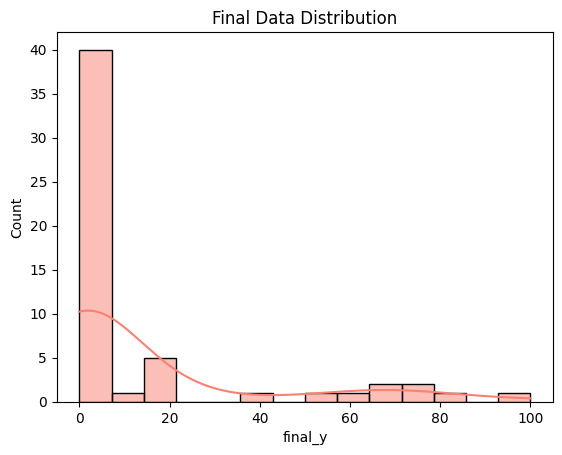

                    smiles_std  final_y
0     *C.*C.O=S(=O)(O)c1ccccc1      0.0
1                *C.*C.OCCOCCO      0.0
2             C=C(C)C(=O)OCCCC      0.0
3    C=CC(C)(CCC=C(C)C)OC(C)=O      1.6
4  C=CCCC(=O)C1=CCCC2(CCCC2)C1      0.0


In [18]:
'''
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import SaltRemover

# 1. 초기화 및 표준화 함수
remover = SaltRemover.SaltRemover()

def standardize(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = remover.StripMol(mol) # (ㄱ) 염 제거
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True) # (ㄴ) 표준화
    return None

# 2. (ㄱ)~(ㄷ) 통합 공정
print("데이터 정제 및 중복 처리 중...")

# 표준화 적용 및 무효 데이터 제거
df_task1['smiles_std'] = df_task1['SMILES'].apply(standardize)
df_clean = df_task1.dropna(subset=['smiles_std'])

# (ㄷ) 10% 기준 필터링 및 평균화 (메서드 체이닝)
df_final = df_clean.groupby('smiles_std')['y_value'].apply(lambda x: 
    x.mean() if np.all(np.abs(x - x.mean()) <= np.abs(x.mean()) * 0.1) else np.nan
).dropna().reset_index().rename(columns={'y_value': 'final_y'})

print(f"최종 데이터 개수: {len(df_final)}")

# 3. (ㄹ) 시각화
sns.histplot(df_final['final_y'], kde=True, color='salmon')
plt.title('Final Data Distribution')
plt.show()

print(df_final.head())
'''

최종 데이터 개수 (5% 기준): 55


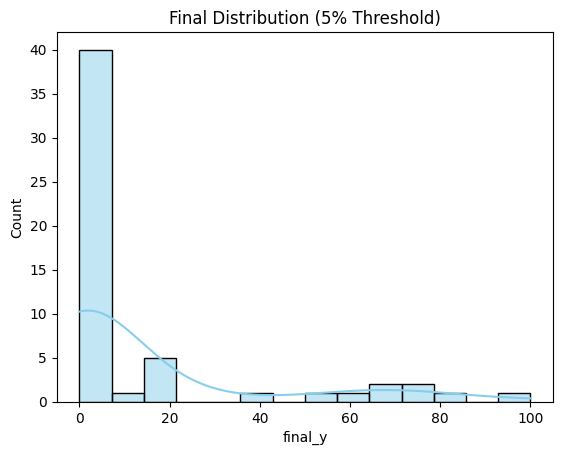

                    smiles_std  final_y
0     *C.*C.O=S(=O)(O)c1ccccc1      0.0
1                *C.*C.OCCOCCO      0.0
2             C=C(C)C(=O)OCCCC      0.0
3    C=CC(C)(CCC=C(C)C)OC(C)=O      1.6
4  C=CCCC(=O)C1=CCCC2(CCCC2)C1      0.0


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import SaltRemover

# 1. 표준화 함수 (ㄱ, ㄴ)
remover = SaltRemover.SaltRemover()
def standardize(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol:
        mol = remover.StripMol(mol)
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)
    return None

# 2. 통합 공정 (ㄷ: 5% 기준 적용)
df_task1['smiles_std'] = df_task1['SMILES'].apply(standardize)

# 0.05(5%) 기준 필터링 및 평균화
df_final = df_task1.dropna(subset=['smiles_std']).groupby('smiles_std')['y_value'].apply(lambda x: 
    x.mean() if np.all(np.abs(x - x.mean()) <= np.abs(x.mean()) * 0.05) else np.nan
).dropna().reset_index().rename(columns={'y_value': 'final_y'})

# 3. 결과 출력 및 시각화 (ㄹ)
print(f"최종 데이터 개수 (5% 기준): {len(df_final)}")

sns.histplot(df_final['final_y'], kde=True, color='skyblue')
plt.title('Final Distribution (5% Threshold)')
plt.show()

print(df_final.head())

R² Score: 0.0058
Coeff: -0.8228, Intercept: 15.4594


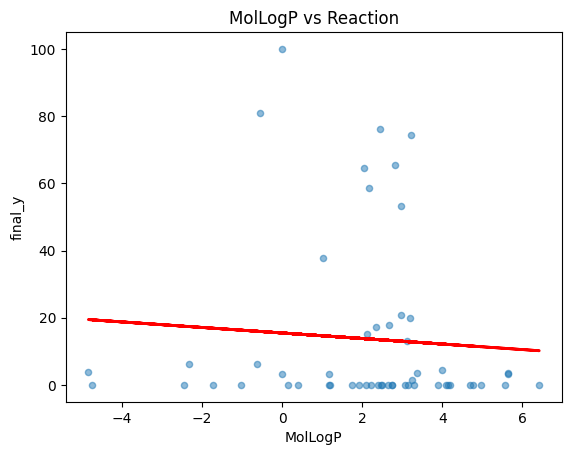

In [22]:
import matplotlib.pyplot as plt
from rdkit.Chem import Descriptors
from sklearn.linear_model import LinearRegression

# (ㄱ) Descriptor 계산 (MolLogP)
df_final['MolLogP'] = df_final['smiles_std'].apply(lambda x: Descriptors.MolLogP(Chem.MolFromSmiles(x)))

# (ㄴ) 모델 학습
X = df_final[['MolLogP']]
y = df_final['final_y']
model = LinearRegression().fit(X, y)

# 결과 출력
print(f"R² Score: {model.score(X, y):.4f}")
print(f"Coeff: {model.coef_[0]:.4f}, Intercept: {model.intercept_:.4f}")

# (ㄷ) 시각화: 산점도 위에 회귀선 그리기
# 선형회귀모델은 '오차제급합'을 최소로 만드는 선을 찾는 것
ax = df_final.plot.scatter(x='MolLogP', y='final_y', alpha=0.5, title='MolLogP vs Reaction')
ax.plot(X, model.predict(X), color='red', linewidth=2) # 모델 예측값으로 선 그리기
plt.show()

모든 Descriptor 계산 중... (잠시만 기다려주세요)

🥇 최적의 Descriptor: EState_VSA2
📊 최고 Score (R²): 0.1454


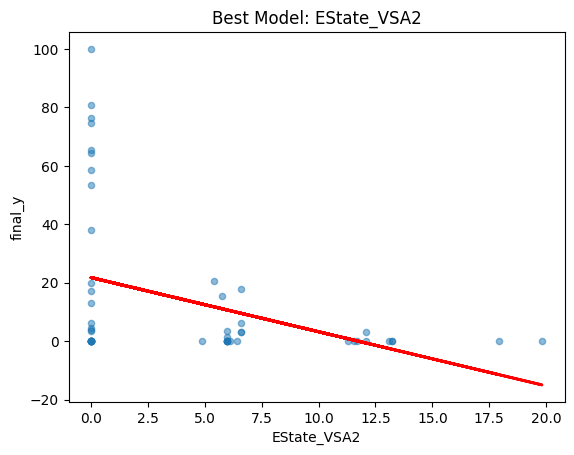

In [27]:
# 모든 Descriptor 후보 리스트 (RDKit 제공 전체)
all_desc = {d[0]: getattr(Descriptors, d[0]) for d in Descriptors._descList}

# 1. 모든 Descriptor 계산 및 결측치 처리
print("모든 Descriptor 계산 중... (잠시만 기다려주세요)")
for name, func in all_desc.items():
    df_final[name] = df_final['smiles_std'].apply(lambda x: func(Chem.MolFromSmiles(x))).replace([np.inf, -np.inf], np.nan).fillna(0)

# 2. 성능(R²) 전수 조사
y = df_final['final_y']
scores = {name: LinearRegression().fit(df_final[[name]], y).score(df_final[[name]], y) for name in all_desc}

# 3. 최고 성능 Descriptor 추출
best_name = max(scores, key=scores.get)
best_score = scores[best_name]

print(f"\n🥇 최적의 Descriptor: {best_name}")
print(f"📊 최고 Score (R²): {best_score:.4f}")

# 4. 최종 모델 시각화 (회귀선 포함)
X_best = df_final[[best_name]]
model_final = LinearRegression().fit(X_best, y)

ax = df_final.plot.scatter(x=best_name, y='final_y', alpha=0.5, title=f'Best Model: {best_name}')
ax.plot(X_best, model_final.predict(X_best), color='red', linewidth=2)
plt.show()
#그래프가 음수가 되는 것 -> EState_VSA2의 수치가 커질수록, 피부 자극 반응값은 낮아진다.

R² Score (0 제외): 0.0964


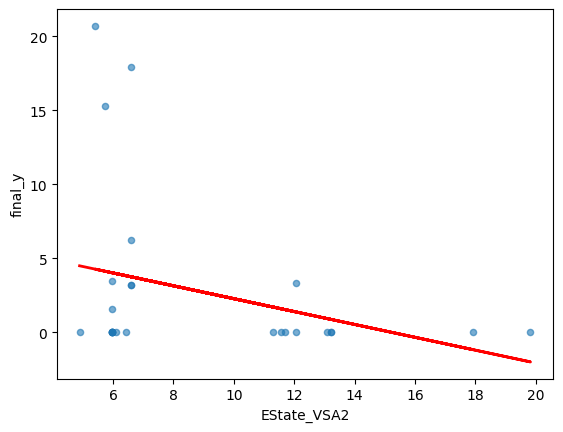

In [24]:
# 위 선형회귀 그래프에 0의 값이 너무 많음 -> 선형회귀모델의 기울기를 외곡(최솟값을 외곡)시킬 수 있다.
# 0의 값을 제거하여 다시 실행해봄

# 1. 'EState_VSA2'가 0이 아닌 데이터만 추출
df_no_zero = df_final[df_final['EState_VSA2'] != 0]

# 2. 모델 학습 및 스코어 계산
X_nz = df_no_zero[['EState_VSA2']]
y_nz = df_no_zero['final_y']
model_nz = LinearRegression().fit(X_nz, y_nz)

print(f"R² Score (0 제외): {model_nz.score(X_nz, y_nz):.4f}")

# 3. 시각화
ax = df_no_zero.plot.scatter(x='EState_VSA2', y='final_y', alpha=0.6)
ax.plot(X_nz, model_nz.predict(X_nz), color='red', linewidth=2)

🥇 Best: SlogP_VSA4 | R²: 0.7361


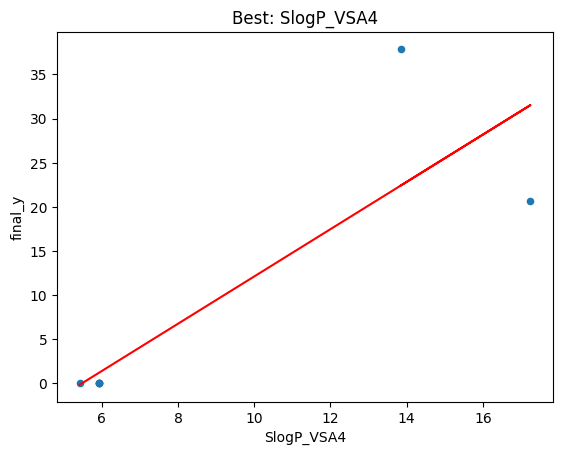

In [26]:
# 지금 코드는 전체 데이터에서 처으부터 0을 제거해본 것

from rdkit.Chem import Descriptors
from sklearn.linear_model import LinearRegression

# 1. 모든 Descriptor 계산 (ㄱ)
all_names = [d[0] for d in Descriptors._descList]
for name in all_names:
    df_final[name] = df_final['smiles_std'].apply(lambda x: getattr(Descriptors, name)(Chem.MolFromSmiles(x))).fillna(0)

# 2. 0 제외 데이터로 전수 조사 (ㄴ)
scores = {}
for n in all_names:
    tmp = df_final[df_final[n] != 0]
    if len(tmp) > 5: # 최소 데이터 확보
        scores[n] = LinearRegression().fit(tmp[[n]], tmp['final_y']).score(tmp[[n]], tmp['final_y'])

best_n = max(scores, key=scores.get)
print(f"🥇 Best: {best_n} | R²: {scores[best_n]:.4f}")

# 3. 최종 모델 시각화 (ㄷ)
df_best = df_final[df_final[best_n] != 0]
X_b, y_b = df_best[[best_n]], df_best['final_y']
model = LinearRegression().fit(X_b, y_b)

ax = df_best.plot.scatter(x=best_n, y='final_y', title=f"Best: {best_n}")
ax.plot(X_b, model.predict(X_b), color='red')

In [28]:
# 1. 각 Descriptor별 0 값의 개수와 비율 계산
zero_stats = []
for name in all_names:
    zero_count = (df_final[name] == 0).sum()
    zero_ratio = zero_count / len(df_final)
    zero_stats.append({'Descriptor': name, 'Zero_Count': zero_count, 'Zero_Ratio': zero_ratio})

# 2. 데이터프레임으로 변환 후 비율이 높은 순으로 정렬
df_zero_report = pd.DataFrame(zero_stats).sort_values(by='Zero_Ratio', ascending=False)

# 3. 상위 10개 출력 (0이 가장 많은 변수들)
print("🚩 0 값의 비율이 높은 Descriptor TOP 10:")
print(df_zero_report.head(10))

# 4. 우리가 찾은 'SlogP_VSA4'의 상태 확인
target_info = df_zero_report[df_zero_report['Descriptor'] == 'SlogP_VSA4']
print(f"\n🔍 SlogP_VSA4의 0 비율: {target_info['Zero_Ratio'].values[0]*100:.2f}%")

🚩 0 값의 비율이 높은 Descriptor TOP 10:
              Descriptor  Zero_Count  Zero_Ratio
10   NumRadicalElectrons          55         1.0
63              SMR_VSA2          55         1.0
69              SMR_VSA8          55         1.0
82            SlogP_VSA9          55         1.0
86          EState_VSA11          55         1.0
50            PEOE_VSA12          55         1.0
203          fr_priamide          55         1.0
170   fr_dihydropyridine          55         1.0
169             fr_diazo          55         1.0
181           fr_isocyan          55         1.0

🔍 SlogP_VSA4의 0 비율: 87.27%


In [29]:
# 1. 0 값의 비율 계산 및 데이터프레임 생성
zero_stats = pd.DataFrame([{
    'Descriptor': name,
    'Zero_Count': (df_final[name] == 0).sum(),
    'Zero_Ratio': (df_final[name] == 0).mean() # 평균을 내면 바로 비율이 됩니다
} for name in all_names])

# 2. 비율이 높은 순(내림차순)으로 정렬
df_zero_top10 = zero_stats.sort_values(by='Zero_Ratio', ascending=False).head(10)

# 3. 결과 출력
print("🚩 [Top 10] 0 데이터가 가장 많이 포함된 Descriptor:")
print(df_zero_top10.to_string(index=False)) # 인덱스 없이 깔끔하게 출력

# 4. (참고) SlogP_VSA4의 순위 확인
rank = zero_stats.sort_values(by='Zero_Ratio', ascending=False).reset_index()
slogp_rank = rank[rank['Descriptor'] == 'SlogP_VSA4'].index[0] + 1
print(f"\n💡 SlogP_VSA4는 전체 중 {slogp_rank}번째로 0이 많습니다.")

🚩 [Top 10] 0 데이터가 가장 많이 포함된 Descriptor:
         Descriptor  Zero_Count  Zero_Ratio
NumRadicalElectrons          55         1.0
           SMR_VSA2          55         1.0
           SMR_VSA8          55         1.0
         SlogP_VSA9          55         1.0
       EState_VSA11          55         1.0
         PEOE_VSA12          55         1.0
        fr_priamide          55         1.0
 fr_dihydropyridine          55         1.0
           fr_diazo          55         1.0
         fr_isocyan          55         1.0

💡 SlogP_VSA4는 전체 중 106번째로 0이 많습니다.
